In [33]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_csv(r'C:\animation_technique_classification\Data\basic_eng\basic_prep.csv')
df.head(5)

,Title,Country,Director,Studio,Animation technique,Release Year,Release month,Release day,is_holiday,Duration_Minutes,movie_category
0,"AAA - The Movie AAA, la película: Sin límite e...",Mexico,Alberto Rodriguez,Promociones Antonio Peña Ánima Estudios,Flash animation,2010,1,22,False,96.0,long
1,Alice in Wonderland (2010 film),United States,Tim Burton,Walt Disney Pictures Roth Films The Zanuck Com...,CGI/Live-Action,2010,3,5,False,108.0,long
2,Animals United Konferenz der Tiere,Germany,"Reinhard Klooss, Holger Tappe",Constantin Film,CG animation,2010,10,7,False,93.0,long
3,Anpanman: Blacknose and the Magical Song ja:それ...,Japan,Jun Kawagoe,"Anpanman Production Committee, TMS Entertainment",Traditional,2014,7,10,False,52.0,standart
4,Las aventuras de Don Quijote,Spain,Antonio Zurera,NaN,Traditional / CG animation,2010,11,26,True,73.0,standart


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                1417 non-null   str    
 1   Country              1417 non-null   str    
 2   Director             1383 non-null   str    
 3   Studio               1308 non-null   str    
 4   Animation technique  1402 non-null   str    
 5   Release Year         1417 non-null   int64  
 6   Release month        1417 non-null   int64  
 7   Release day          1417 non-null   int64  
 8   is_holiday           1417 non-null   bool   
 9   Duration_Minutes     1386 non-null   float64
 10  movie_category       1386 non-null   str    
dtypes: bool(1), float64(1), int64(3), str(6)
memory usage: 112.2 KB


In [18]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "str":
        df[col] = encoder.fit_transform(df[col])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                1417 non-null   int64  
 1   Country              1417 non-null   int64  
 2   Director             1417 non-null   int64  
 3   Studio               1417 non-null   int64  
 4   Animation technique  1417 non-null   int64  
 5   Release Year         1417 non-null   int64  
 6   Release month        1417 non-null   int64  
 7   Release day          1417 non-null   int64  
 8   is_holiday           1417 non-null   bool   
 9   Duration_Minutes     1386 non-null   float64
 10  movie_category       1417 non-null   int64  
dtypes: bool(1), float64(1), int64(9)
memory usage: 112.2 KB


In [20]:
df.head()

,Title,Country,Director,Studio,Animation technique,Release Year,Release month,Release day,is_holiday,Duration_Minutes,movie_category
0,24,82,26,540,31,2010,1,22,False,96.0,1
1,46,132,903,763,23,2010,3,5,False,108.0,1
2,69,50,721,186,7,2010,10,7,False,93.0,1
3,73,73,432,66,50,2014,7,10,False,52.0,3
4,675,112,56,830,51,2010,11,26,True,73.0,3


In [21]:
# Input vs Output
num_features = df.select_dtypes(include=[np.number])
y = df['Animation technique']

#pearson correlation
pearson = df[num_features.columns].corrwith(y, method='pearson')
print(f'Peason correlatoon:{pearson}')

Peason correlatoon:Title                 -0.048706
Country               -0.051492
Director               0.140659
Studio                 0.112234
Animation technique    1.000000
Release Year          -0.056930
Release month         -0.041345
Release day            0.052104
Duration_Minutes       0.025624
movie_category        -0.081832
dtype: float64


In [22]:
pearson.sort_values(ascending=False)

Animation technique    1.000000
Director               0.140659
Studio                 0.112234
Release day            0.052104
Duration_Minutes       0.025624
Release month         -0.041345
Title                 -0.048706
Country               -0.051492
Release Year          -0.056930
movie_category        -0.081832
dtype: float64

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

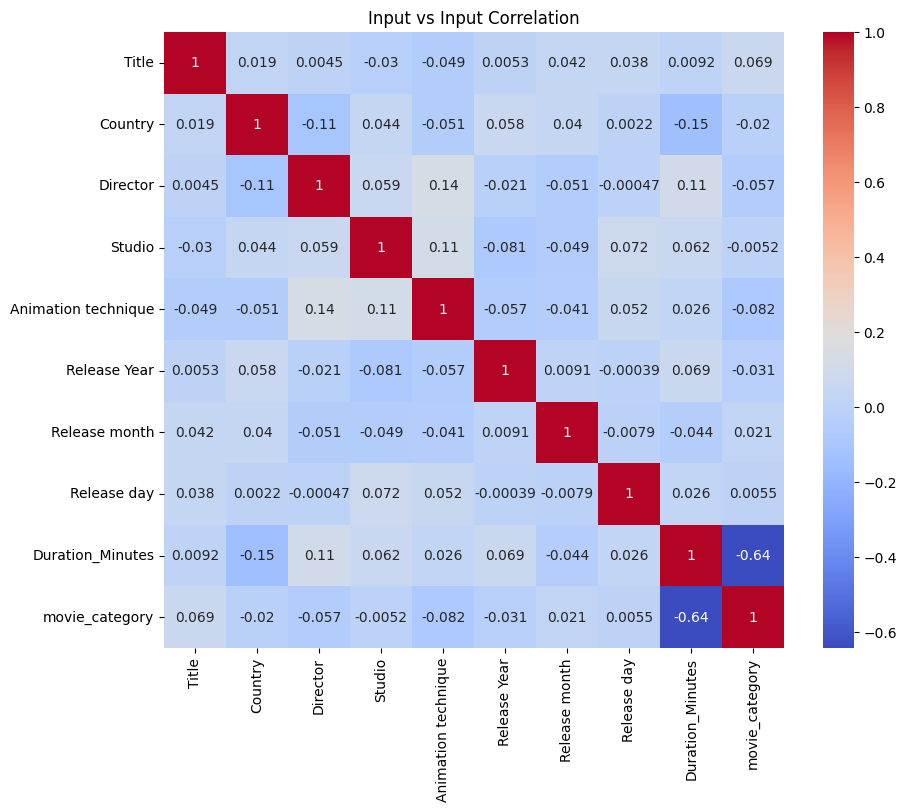

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_features.columns].corr(), annot=True, cmap='coolwarm')
plt.title("Input vs Input Correlation")
plt.show()

In [25]:
corr_matrix = df[num_features.columns].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# np.ones => creates array with the shape of corr_matrix
# np.trui => traingle upper, k = 1 => selected the upper from the main diagonal
to_drop = [column for column in upper.columns if any(upper[column] > 0.2)]
print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['movie_category']


In [26]:
upper

,Title,Country,Director,Studio,Animation technique,Release Year,Release month,Release day,Duration_Minutes,movie_category
Title,NaN,0.019061,0.004459,0.029617,0.048706,0.005291,0.042106,0.038404,0.009169,0.069249
Country,NaN,NaN,0.105820,0.043619,0.051492,0.058267,0.039729,0.002214,0.146200,0.019862
Director,NaN,NaN,NaN,0.059360,0.140659,0.021070,0.051441,0.000474,0.105495,0.056881
Studio,NaN,NaN,NaN,NaN,0.112234,0.080894,0.049233,0.072313,0.062101,0.005242
Animation technique,NaN,NaN,NaN,NaN,NaN,0.056930,0.041345,0.052104,0.025624,0.081832
Release Year,NaN,NaN,NaN,NaN,NaN,NaN,0.009078,0.000388,0.069375,0.031458
Release month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007859,0.043623,0.021438
Release day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025774,0.005464
Duration_Minutes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.641586
movie_category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import plotly.express as px

corr_matrix = df[num_features.columns].corr()

fig = px.imshow(
    corr_matrix, 
    text_auto=True,
    color_continuous_scale='RdBu_r',
    origin='upper',
    labels=dict(x = 'Features', y = 'Features', color = 'Correlation'),
    title='Feagure to Feagure Correlation (Plotly Express)'
)
fig.update_xaxes(side = 'top')
fig.show()

    From the Correlation Matrix, we can feagure it out that 
    2 feagures are highly correlated to each other, 
    with the previous analysis with pearson, dropping 'Movie Category' makes more sense

In [102]:
# Need to drop the sellected features
# In order to prevent the Data Leakage, we are not using the encoded df

df = pd.read_csv(r'C:\animation_technique_classification\Data\basic_eng\basic_prep.csv')
df = df.drop(to_drop, axis=1)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                1417 non-null   str    
 1   Country              1417 non-null   str    
 2   Director             1383 non-null   str    
 3   Studio               1308 non-null   str    
 4   Animation technique  1402 non-null   str    
 5   Release Year         1417 non-null   int64  
 6   Release month        1417 non-null   int64  
 7   Release day          1417 non-null   int64  
 8   is_holiday           1417 non-null   bool   
 9   Duration_Minutes     1386 non-null   float64
dtypes: bool(1), float64(1), int64(3), str(5)
memory usage: 101.1 KB


Feature Selection

In [103]:
df.isnull().sum()

Title                    0
Country                  0
Director                34
Studio                 109
Animation technique     15
Release Year             0
Release month            0
Release day              0
is_holiday               0
Duration_Minutes        31
dtype: int64

In [104]:
df = df.dropna(subset=['Animation technique'])

In [105]:
le = LabelEncoder()
std_scalar = StandardScaler()

for col in df.columns:
    if df[col].isnull().sum() >= 1 and df[col].dtype == "str":
        df[col] = df[col].fillna(df[col].mode()[0])
    if df[col].isnull().sum() >= 1 and df[col].dtype != "str":
        df[col] = df[col].fillna(value=df[col].mean())

In [108]:
df.head(3)

,Title,Country,Director,Studio,Animation technique,Release Year,Release month,Release day,is_holiday,Duration_Minutes
0,"AAA - The Movie AAA, la película: Sin límite e...",Mexico,Alberto Rodriguez,Promociones Antonio Peña Ánima Estudios,Flash animation,2010,1,22,False,96.0
1,Alice in Wonderland (2010 film),United States,Tim Burton,Walt Disney Pictures Roth Films The Zanuck Com...,CGI/Live-Action,2010,3,5,False,108.0
2,Animals United Konferenz der Tiere,Germany,"Reinhard Klooss, Holger Tappe",Constantin Film,CG animation,2010,10,7,False,93.0


In [109]:
for col in df.columns:
    if df[col].dtype == "str":
        df[col] = encoder.fit_transform(df[col])

for col in df.columns.drop('Animation technique'):
    df[col] = std_scalar.fit_transform(df[[col]])

In [111]:
df.isna().sum()

Title                  0
Country                0
Director               0
Studio                 0
Animation technique    0
Release Year           0
Release month          0
Release day            0
is_holiday             0
Duration_Minutes       0
dtype: int64

In [112]:
X = df.drop('Animation technique', axis=1)
y = df['Animation technique'].copy()


In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [114]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [115]:
important_features = rf.feature_importances_
iportant_features = pd.Series(important_features, index=X_train.columns).sort_values(ascending=False)

In [116]:
iportant_features

Country             0.225915
Studio              0.147464
Duration_Minutes    0.126411
Title               0.123645
Director            0.115965
Release Year        0.099455
Release day         0.085800
Release month       0.063577
is_holiday          0.011767
dtype: float64

In [117]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [128]:
lr_importance = lr.coef_[0]

lr_importance = pd.Series(lr_importance, index=X_train.columns).sort_values(ascending=False)
lr_importance

Title               0.579241
Release month       0.209796
Release Year        0.122509
Release day         0.089474
Director            0.048698
Studio             -0.181002
is_holiday         -0.321885
Duration_Minutes   -0.452011
Country            -0.542565
dtype: float64

Handling skewness

In [148]:
df = pd.read_csv(r'C:\animation_technique_classification\Data\basic_eng\basic_prep.csv')
df = df.drop(to_drop, axis=1)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                1417 non-null   str    
 1   Country              1417 non-null   str    
 2   Director             1383 non-null   str    
 3   Studio               1308 non-null   str    
 4   Animation technique  1402 non-null   str    
 5   Release Year         1417 non-null   int64  
 6   Release month        1417 non-null   int64  
 7   Release day          1417 non-null   int64  
 8   is_holiday           1417 non-null   bool   
 9   Duration_Minutes     1386 non-null   float64
dtypes: bool(1), float64(1), int64(3), str(5)
memory usage: 101.1 KB


In [149]:
X = df.drop('Animation technique', axis=1)
y = df['Animation technique'].copy()

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [151]:
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns.to_list()

skewness = X_train[num_features].skew()

skewed_features = skewness[abs(skewness) > 0.5].index.to_list()
skewed_features

[]

In [152]:
skewness

Release Year        0.122715
Release month      -0.184930
Release day         0.013299
Duration_Minutes   -0.129426
dtype: float64

As the skewness is not that high in our dataset, there is no need to use np.log1p()

In [153]:
techniques = [
    'Traditional', 'CG animation', 'Flash animation', 
    'CGI animation', 'Computer', 'Stop motion'
]

df2 = df[df['Animation technique'].isin(techniques)]

In [155]:
df2.info()

<class 'pandas.DataFrame'>
Index: 1271 entries, 0 to 1416
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                1271 non-null   str    
 1   Country              1271 non-null   str    
 2   Director             1241 non-null   str    
 3   Studio               1178 non-null   str    
 4   Animation technique  1271 non-null   str    
 5   Release Year         1271 non-null   int64  
 6   Release month        1271 non-null   int64  
 7   Release day          1271 non-null   int64  
 8   is_holiday           1271 non-null   bool   
 9   Duration_Minutes     1245 non-null   float64
dtypes: bool(1), float64(1), int64(3), str(5)
memory usage: 100.5 KB


In [157]:
df2['Animation technique'].value_counts()

Animation technique
Traditional        688
CG animation       416
Flash animation     71
CGI animation       54
Computer            27
Stop motion         15
Name: count, dtype: int64